# Chapter 96 - Clean Conceptual Recap

This final chapter follows one tiny example from raw text through training and generation.

The goal is to connect the parts of a language model into one accurate mental model.

## Learning goals

By the end of this chapter, you will be able to explain how:

- text becomes tokens and token IDs;
- token IDs become token embeddings with position information;
- causal transformer blocks build context-dependent representations;
- an output layer produces next-token logits;
- softmax converts logits into a probability distribution;
- cross-entropy scores known target tokens during training;
- backpropagation computes parameter gradients;
- an optimizer updates parameters; and
- generation repeatedly predicts and appends one token without updating parameters.

## The central idea

A language model is a learned function that maps a context of previous tokens to scores for the next token.

Training adjusts the function so correct next tokens receive better scores.

Generation repeatedly uses the fitted function to extend a context.

Every component in this chapter serves one of those three statements.

## Represent text as discrete data

**Text** is the raw string that people read.

A **tokenizer** splits text into units called **tokens**.

A token can be a character, word, byte, or subword piece, depending on the tokenizer.

A **token ID** is an integer label assigned to a token, not a numerical measure of its meaning.

We will use characters so every step remains visible.

In [1]:
import torch  # noqa: I001


training_text = ("the cat sat.\nthe cat ran.\nthe dog sat.\n") * 20
characters = sorted(set(training_text))
character_to_id = {
    character: character_id for character_id, character in enumerate(characters)
}
id_to_character = {
    character_id: character for character, character_id in character_to_id.items()
}


def encode_text(text: str) -> list[int]:
    return [character_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


example_text = "the cat sat."
example_tokens = list(example_text)
example_ids = encode_text(example_text)

print("text:", repr(example_text))
print("tokens:", example_tokens)
print("token IDs:", example_ids)
print("round trip:", decode_token_ids(example_ids))
print("vocabulary:", character_to_id)

text: 'the cat sat.'
tokens: ['t', 'h', 'e', ' ', 'c', 'a', 't', ' ', 's', 'a', 't', '.']
token IDs: [13, 8, 6, 1, 4, 3, 13, 1, 12, 3, 13, 2]
round trip: the cat sat.
vocabulary: {'\n': 0, ' ': 1, '.': 2, 'a': 3, 'c': 4, 'd': 5, 'e': 6, 'g': 7, 'h': 8, 'n': 9, 'o': 10, 'r': 11, 's': 12, 't': 13}


The round trip demonstrates that encoding and decoding preserve the example.

Changing the ID assignment would not change the text as long as the encoder and decoder changed together.

## Create next-token training pairs

Autoregressive training uses a sequence as input and the same sequence shifted one position as the target.

At every input position, the model is scored against the token that actually followed it.

In [2]:
example_id_tensor = torch.tensor([example_ids], dtype=torch.long)
input_ids = example_id_tensor[:, :-1]
target_ids = example_id_tensor[:, 1:]

print("input text: ", repr(decode_token_ids(input_ids[0].tolist())))
print("target text:", repr(decode_token_ids(target_ids[0].tolist())))
print("input shape:", tuple(input_ids.shape))
print("target shape:", tuple(target_ids.shape))
print()
print("first four prediction tasks:")
for position in range(4):
    context = decode_token_ids(input_ids[0, : position + 1].tolist())
    target = decode_token_ids([int(target_ids[0, position].item())])
    print(f"{context!r} -> {target!r}")

input text:  'the cat sat'
target text: 'he cat sat.'
input shape: (1, 11)
target shape: (1, 11)

first four prediction tasks:
't' -> 'h'
'th' -> 'e'
'the' -> ' '
'the ' -> 'c'


The shift turns one short string into several supervised predictions.

The model predicts all target positions in parallel during training, even though causal masking prevents any position from reading future inputs.

## Turn IDs into contextual vectors

An **embedding** is a learned vector retrieved by token ID.

A learned **position embedding** represents where a token occurs in the current sequence.

Their elementwise sum gives every position token identity and order information.

A **transformer block** then applies causal self-attention and a feedforward network, with layer normalization and residual connections.

Causal attention lets a position combine information from itself and earlier positions, but not later positions.

In [3]:
class RecapTransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = torch.nn.MultiheadAttention(
            embedding_dimension,
            number_of_attention_heads,
            batch_first=True,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 2 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(2 * embedding_dimension, embedding_dimension),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        sequence_length = input_values.shape[1]
        causal_mask = torch.triu(
            torch.ones(sequence_length, sequence_length, dtype=torch.bool),
            diagonal=1,
        )
        normalized_values = self.attention_norm(input_values)
        attention_output, _ = self.attention(
            normalized_values,
            normalized_values,
            normalized_values,
            attn_mask=causal_mask,
            need_weights=False,
        )
        values_after_attention = input_values + attention_output
        feedforward_output = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_output
        return output_values


class RecapLanguageModel(torch.nn.Module):
    context_length: int
    vocabulary_size: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
    ) -> None:
        super().__init__()
        self.context_length = context_length
        self.vocabulary_size = vocabulary_size
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.transformer_block = RecapTransformerBlock(
            embedding_dimension, number_of_attention_heads
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        if token_ids.ndim != 2:
            raise ValueError("token_ids must have shape [batch, time].")
        sequence_length = token_ids.shape[1]
        if sequence_length > self.context_length:
            raise ValueError("The input exceeds the model context length.")
        position_ids = torch.arange(sequence_length, device=token_ids.device)
        token_vectors = self.token_embedding(token_ids)
        position_vectors = self.position_embedding(position_ids)
        combined_vectors = token_vectors + position_vectors
        contextual_vectors = self.transformer_block(combined_vectors)
        normalized_vectors = self.final_norm(contextual_vectors)
        logits: torch.Tensor = self.output_layer(normalized_vectors)
        return logits

This one-block model is deliberately smaller than the TinyGPT used in earlier projects, but the data flow is the same.

The output layer maps each final position vector to one logit per vocabulary token.

In [4]:
torch.manual_seed(96)
model = RecapLanguageModel(
    vocabulary_size=len(characters),
    context_length=16,
    embedding_dimension=24,
    number_of_attention_heads=4,
)

token_vectors = model.token_embedding(input_ids)
position_ids = torch.arange(input_ids.shape[1])
combined_vectors = token_vectors + model.position_embedding(position_ids)
logits = model(input_ids)

print("token IDs:", tuple(input_ids.shape))
print("token embeddings:", tuple(token_vectors.shape))
print("combined vectors:", tuple(combined_vectors.shape))
print("next-token logits:", tuple(logits.shape))
print("parameters:", sum(parameter.numel() for parameter in model.parameters()))

token IDs: (1, 11)
token embeddings: (1, 11, 24)
combined vectors: (1, 11, 24)
next-token logits: (1, 11, 14)
parameters: 5990


The last logit dimension equals the vocabulary size because every position predicts every possible next character.

The middle dimension remains the sequence length because training makes a prediction at each position.

## Convert logits into probabilities

A **logit** is an unrestricted score, so logits need not be positive or sum to one.

**Softmax** converts a vector of logits into nonnegative probabilities that sum to one.

The relative logit differences determine the probabilities.

In [5]:
final_position_logits = logits[0, -1]
final_position_probabilities = torch.softmax(final_position_logits, dim=-1)
top_probabilities, top_ids = torch.topk(final_position_probabilities, k=4)

print("probability sum:", final_position_probabilities.sum().item())
print("top next-character probabilities before training:")
for probability, token_id in zip(top_probabilities, top_ids, strict=True):
    character = id_to_character[token_id.item()]
    print(f"  {character!r}: {probability.item():.3f}")

probability sum: 1.0
top next-character probabilities before training:
  'g': 0.126
  'h': 0.101
  'r': 0.093
  'n': 0.092


These probabilities come from random initial parameters, so their ranking has no learned significance yet.

Softmax describes the predictive distribution but does not update the model.

## Measure error and update parameters

**Cross-entropy loss** rewards a high logit for each known target relative to the competing logits.

PyTorch cross-entropy accepts logits directly and internally combines log-softmax with negative log likelihood.

**Backpropagation** applies the chain rule to compute the gradient of loss with respect to every trainable parameter.

An **optimizer** uses those gradients to update the parameter values.

The next cell performs one complete training step and verifies that a parameter changed.

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)
training_logits = model(input_ids)
loss_before_update = torch.nn.functional.cross_entropy(
    training_logits.reshape(-1, model.vocabulary_size),
    target_ids.reshape(-1),
)
parameter = model.output_layer.weight
parameter_value_before = parameter[0, 0].item()

optimizer.zero_grad(set_to_none=True)
loss_before_update.backward()  # type: ignore[no-untyped-call]
if parameter.grad is None:
    raise RuntimeError("The output layer should have a gradient after backpropagation.")
gradient_norm = parameter.grad.norm().item()
optimizer.step()
parameter_value_after = parameter[0, 0].item()

print("loss before update:", round(loss_before_update.item(), 4))
print("output-layer gradient norm:", round(gradient_norm, 4))
print("selected parameter before:", round(parameter_value_before, 6))
print("selected parameter after: ", round(parameter_value_after, 6))
print("parameter changed:", parameter_value_before != parameter_value_after)

loss before update: 2.5883
output-layer gradient norm: 1.4025
selected parameter before: 0.129412
selected parameter after:  0.139399
parameter changed: True


The gradient is the information produced by backpropagation, while the changed parameter is the optimizer's effect.

One update does not train a useful language model, so we now repeat the same operations over many shifted windows.

In [7]:
all_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
window_size = 12
windows = all_token_ids.unfold(0, window_size + 1, 1)[::2]
training_inputs = windows[:, :-1]
training_targets = windows[:, 1:]

initial_corpus_loss = torch.nn.functional.cross_entropy(
    model(training_inputs).reshape(-1, model.vocabulary_size),
    training_targets.reshape(-1),
).item()

for _training_step in range(100):
    corpus_logits = model(training_inputs)
    corpus_loss = torch.nn.functional.cross_entropy(
        corpus_logits.reshape(-1, model.vocabulary_size),
        training_targets.reshape(-1),
    )
    optimizer.zero_grad(set_to_none=True)
    corpus_loss.backward()  # type: ignore[no-untyped-call]
    optimizer.step()

final_corpus_loss = torch.nn.functional.cross_entropy(
    model(training_inputs).reshape(-1, model.vocabulary_size),
    training_targets.reshape(-1),
).item()

print("training windows:", len(training_inputs))
print("loss before repeated updates:", round(initial_corpus_loss, 4))
print("loss after repeated updates: ", round(final_corpus_loss, 4))

training windows: 384
loss before repeated updates: 2.3417
loss after repeated updates:  0.1001


The lower training loss means the model assigns better relative scores to next characters in these repeated training windows.

It does not establish validation quality, originality, factual accuracy, or general reasoning.

## Generate by repeating prediction

During generation, target tokens are unknown, so there is no loss, backward pass, or optimizer update.

The model runs a forward pass, converts the final-position logits to probabilities, chooses one token, appends it, and repeats.

When the sequence exceeds the context length, only the newest tokens remain visible.

In [8]:
@torch.no_grad()
def generate_text(
    model: RecapLanguageModel,
    prompt: str,
    number_of_new_tokens: int,
    random_seed: int,
    temperature: float = 0.8,
) -> str:
    if temperature <= 0:
        raise ValueError("temperature must be positive.")
    model.eval()
    generated_ids = torch.tensor([encode_text(prompt)], dtype=torch.long)
    generator = torch.Generator().manual_seed(random_seed)
    for _ in range(number_of_new_tokens):
        visible_ids = generated_ids[:, -model.context_length :]
        next_logits = model(visible_ids)[:, -1] / temperature
        next_probabilities = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(
            next_probabilities, num_samples=1, generator=generator
        )
        generated_ids = torch.cat([generated_ids, next_id], dim=1)
    return decode_token_ids(generated_ids[0].tolist())


generated_text = generate_text(
    model,
    prompt="the cat",
    number_of_new_tokens=48,
    random_seed=9601,
)
print(generated_text)

the cat ran.
te dog dog san.
the sat cat rat dog dog do


The generated continuation reflects the tiny repeated corpus and may reproduce its short patterns.

Its purpose is to verify the autoregressive loop, not to demonstrate broad language ability.

## Keep training and generation distinct

| Stage | Known target? | Cross-entropy? | Backpropagation? | Parameter update? |
| --- | --- | --- | --- | --- |
| Training | Yes | Yes | Yes | Yes |
| Generation | No | No | No | No |

Both stages use the same learned forward computation through embeddings, transformer blocks, and the output layer.

They differ in what happens after the logits are produced.

## The complete pipeline

The final diagram separates the shared forward path from the two operations that can follow it.

The training branch uses known targets to update parameters, while the generation branch samples and feeds a token back into the next context.

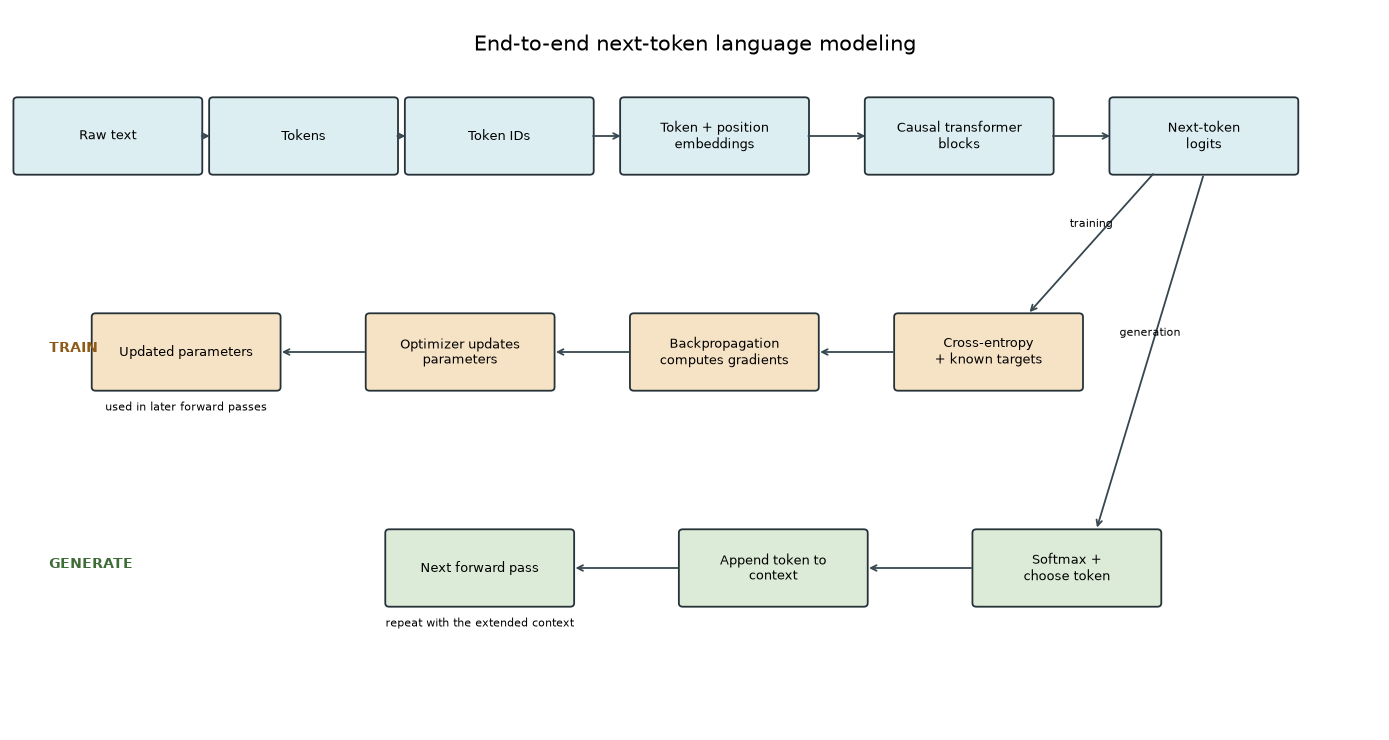

In [9]:
import matplotlib.pyplot as plt  # noqa: I001
from matplotlib.axes import Axes
from matplotlib.patches import FancyBboxPatch


def draw_box(
    axis: Axes,
    center_x: float,
    center_y: float,
    label: str,
    color: str,
    width: float = 1.85,
    height: float = 0.78,
) -> None:
    box = FancyBboxPatch(
        (center_x - width / 2, center_y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.04",
        linewidth=1.3,
        edgecolor="#263238",
        facecolor=color,
    )
    axis.add_patch(box)
    axis.text(center_x, center_y, label, ha="center", va="center", fontsize=9)


def draw_arrow(
    axis: Axes,
    start: tuple[float, float],
    end: tuple[float, float],
    label: str = "",
) -> None:
    axis.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "linewidth": 1.3, "color": "#37474f"},
    )
    if label:
        axis.text(
            (start[0] + end[0]) / 2,
            (start[1] + end[1]) / 2 + 0.18,
            label,
            ha="center",
            fontsize=8,
        )


figure, axis = plt.subplots(figsize=(14, 7.5))
axis.set_xlim(0, 14)
axis.set_ylim(0, 8)
axis.axis("off")

forward_color = "#dceef2"
training_color = "#f6e3c5"
generation_color = "#dcebd7"

forward_steps = [
    (1.0, "Raw text"),
    (3.0, "Tokens"),
    (5.0, "Token IDs"),
    (7.2, "Token + position\nembeddings"),
    (9.7, "Causal transformer\nblocks"),
    (12.2, "Next-token\nlogits"),
]
for center_x, label in forward_steps:
    draw_box(axis, center_x, 6.6, label, forward_color)
for (left_x, _left_label), (right_x, _right_label) in zip(
    forward_steps, forward_steps[1:], strict=False
):
    draw_arrow(axis, (left_x + 0.93, 6.6), (right_x - 0.93, 6.6))

draw_box(axis, 10.0, 4.2, "Cross-entropy\n+ known targets", training_color)
draw_box(axis, 7.3, 4.2, "Backpropagation\ncomputes gradients", training_color)
draw_box(axis, 4.6, 4.2, "Optimizer updates\nparameters", training_color)
draw_box(axis, 1.8, 4.2, "Updated parameters", training_color)
draw_arrow(axis, (11.7, 6.2), (10.4, 4.62), "training")
draw_arrow(axis, (9.05, 4.2), (8.25, 4.2))
draw_arrow(axis, (6.35, 4.2), (5.55, 4.2))
draw_arrow(axis, (3.65, 4.2), (2.75, 4.2))
axis.text(1.8, 3.55, "used in later forward passes", ha="center", fontsize=8)

draw_box(axis, 10.8, 1.8, "Softmax +\nchoose token", generation_color)
draw_box(axis, 7.8, 1.8, "Append token to\ncontext", generation_color)
draw_box(axis, 4.8, 1.8, "Next forward pass", generation_color)
draw_arrow(axis, (12.2, 6.18), (11.1, 2.22), "generation")
draw_arrow(axis, (9.85, 1.8), (8.75, 1.8))
draw_arrow(axis, (6.85, 1.8), (5.75, 1.8))
axis.text(4.8, 1.15, "repeat with the extended context", ha="center", fontsize=8)

axis.text(
    7.0, 7.55, "End-to-end next-token language modeling", ha="center", fontsize=15
)
axis.text(0.4, 4.2, "TRAIN", fontsize=10, fontweight="bold", color="#8d5a18")
axis.text(0.4, 1.8, "GENERATE", fontsize=10, fontweight="bold", color="#3f6b37")
plt.tight_layout()
plt.show()

Read the blue row from left to right for the shared forward computation.

Follow the tan branch when correct targets are available and parameters should learn.

Follow the green branch when using fixed trained parameters to extend text.

The labels beneath the final boxes identify the two loops: updated parameters affect later training passes, while appended token IDs affect later generation passes.

## Resolve common confusions

- Token IDs are arbitrary labels; embeddings are learned numerical representations.
- Position embeddings supply order information that token embeddings alone do not contain.
- Attention builds context-dependent vectors; it does not directly choose the next token.
- The output layer produces logits; softmax turns a selected logit vector into probabilities.
- Cross-entropy measures predictions against known targets; softmax alone does not train anything.
- Backpropagation computes gradients; the optimizer uses them to change parameters.
- Training predicts all shifted targets in parallel under a causal mask.
- Generation predicts and appends one new token at a time without gradients.
- The context window limits which prior tokens can directly affect a prediction.
- Better next-token loss does not by itself establish truth, reasoning, originality, or safety.

## The whole chain in order

1. Collect and inspect raw text.
2. Tokenize the text and map tokens to integer IDs.
3. Shift token sequences to create inputs and next-token targets.
4. Look up token embeddings and add position embeddings.
5. Process the vectors with causally masked transformer blocks.
6. Project each final vector to vocabulary logits.
7. During training, compare logits with known targets using cross-entropy.
8. Backpropagate the loss to compute gradients.
9. Let the optimizer update parameters and repeat over examples.
10. During generation, apply softmax to final-position logits and choose a token.
11. Append that token, crop to the context window when necessary, and repeat.

This sequence connects data representation, model computation, learning, and generation without treating any one component as the whole system.

## Takeaways

- The prediction task is stable across count models, MLPs, and GPTs: estimate the next token from previous tokens.
- Tokenization defines the discrete units, while embeddings provide learned continuous vectors.
- Causal attention lets each position use only allowed earlier context.
- Logits are scores, softmax produces probabilities, and cross-entropy uses known targets to measure error.
- Backpropagation and the optimizer form the parameter-learning loop.
- Autoregressive generation reuses the forward pass but does not train the model.
- Evaluation is part of the pipeline because a running model is not automatically a useful or reliable model.

The course's central achievement is making this complete chain inspectable from raw text to generated text.